# Super-Resolution Time Difference of Arrival Estimation

### Jimmy Jamison

This notebook explores using the MUltiple Signal Classification (MUSIC) algorithm for super-resolution time difference of arrival estimation.

MUSIC is an algorithm for frequency estimation, and is commonly used for spectral estimation and RF signal direction finding. MUSIC structures these problems as parameter estimation of complex sinusoids in additive noise. See [1] for more information.

Time difference of arrival (TDOA) estimation can also be formulated in a way to use the MUSIC algorithm. Assume the same transmitted source signal is received at two sensors:

$y_0(n) = \sum_{i=0}^{D_0} \alpha_{0i}s(n-\tau_{0i}) + w_0(n)$

$y_1(n) = \sum_{i=0}^{D_1} \alpha_{1i}s(n-\tau_{1i}) + w_1(n)$

for $n = 0, 1, ... N-1 $

where $s(n)$ is the source signal, $y_0(n)$ and $y_1(n)$ are the received signals at sensors 0 and 1 respectively, $N$ is the number of observed samples, $D_0$ and $D_1$ are the number of multipath components at each sensor, $\tau_{0i}$ and $\tau_{1i}$ are the time delays of the multipath components at each sensor, $\alpha_{0i}$ and $\alpha_{1i}$ are the random amplitudes of the multipath components, and $w_0(t)$ and $w_1(t)$ are additive white Gaussian noise at each sensor.

The cross correlation and cross spectrum are defined as:

$r_{y_0y_1}(m) = E[ y_0(n) y_1^*(n+m) ]$

$S_{y_0y_1}(w) = \mathcal{F} [r_{y_0y_1}(m) ] $

where $\mathcal{F}$ represents the discrete Fourier transform.

[2] defines the "normalized cross spectrum" as:

$h(w) = \frac{S_{y_0y_1}(w)}{S_{y_0y_0}(w)}$

where $S_{y_0y_0}(w)$ is the power spectral density of $y_0(n)$.

The time differences of arrival between $y_0(n)$ and $y_1(n)$ (ie peaks in the cross correlation $r_{y_0y_1}(m)$) manifest as complex sinusoids in the normalized cross spectrum. Therefore the problem of time difference of arrival estimation can be formulated as parameter estimation of complex sinusoids in the normalized cross spectrum. For simplicity, its assumed here that $D_0=1$ and $D_1>1$ but the results can be extended to $D_0>1$. $h(w)$ can be written as:

$h(w) = \sum_{i=1}^{D_1} \alpha_{1i}e^{-j w \tau_{1i}} - \epsilon (w)$

If $R$ is the $m$ x $m$ covariance matrix of $h(w)$, then $R$ can be factored as:

$R = Q \Lambda Q^H$

where $\Lambda$ is a diagonal matrix of the eigenvalues of $R$, and $Q$ is a square matrix whose $i$-th column is the eigenvector corresponding to the $i$-th eigenvalue. The matrix $R$ consists of both signal and noise, and the $k$ eigenvectors corresponding to the $k$ largest eigenvalues correspond to signals, and the remaining $m-k$ eigenvectors span the noise space.

The MUSIC algorithm works by seperating the signal and noise subspaces of $R$, then multiplying the steering vector (or array manifold vector in the case of DOA) onto the noise subspace. For TDOA estimation, the steering vector consists of the complex exponentials corresponding to each possible TDOA. This steering vector will be orthogonal to the noise subspace at the $\tau$'s corresponding to the TDOAs between signal components at each sensor. Therefore the MUSIC pseudo-spectrum is:

$P_{MUSIC}(\tau) = \frac{1}{||a^H(\tau) \hat{G}||_2^2}$

where $a(\tau)$ is the steering vector of complex exponentials corresponding to TDOA's $\tau$, $\hat{G}$ is the estimate of $G$ formed by seperating the signal and noise eigenvectors of the covariance matrix $R$, and $|| \centerdot ||_2$ is the 2-norm.

Peaks in $P_{MUSIC}(\tau)$ correspond to the TDOA estimates.

Two important things to note:

1. This method only estimates the frequency of the complex exponentials, not their amplitudes. The peak amplitude in the pseudo-spectrum *does not* neccessarily correspond to the signal component amplitudes.
2. This method assumes $k$ is known in advance and therefore requires a reliable way to estimate $k$ as a pre-processing step.

One other note - in my implementation I had better performance when normalizing the cross spectrum by the PSDs of both sensor signals. So my "normalized cross spectrum" closely resembles the "coherence" function:


$h(w) = \frac{S_{y_0y_1}(w)}{\sqrt{S_{y_0y_0}(w) S_{y_1y_1}(w)}}$

References:

[1] R. O. Schmidt, “A signal subspace approach to multiple emitter location and spectral estimation,” Ph.D. dissertation, Dept. Electr. Eng., Stanford Univ., Stanford, CA, 1981.

[2] Zhong, S., Xia, W., Song, J., & He, Z. “Super-Resolution Time Delay Estimation in Multipath Environments Using Normalized Cross Spectrum.”


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys
import os
sys.path.append(os.path.abspath('..'))
import utils

# TDOA Simulation

Here the TDOA estimates via cross correlation and MUSIC are found for 4 cases with varying degrees of multipath, and the estimates are compared. The simulation specs are as follows:

- Over-sampled QPSK signal is received at each sensor
    - 10 samples per symbol
    - 40 symbols are received (ie signal is 400 samples)
- 20dB SNR for all receive signal components (including multipath)
- 500 samples of data collected at each sensor (ie there is some noise before and after the signal at each sensor)

In this test, a single $M$ x $M$ covariance matrix is computed over the entire 500 sample receive buffer, resulting in a M = 2*N-1 = 999 x 999 covariance matrix. This test assumes that the number of signal components $k$ is known.

Two "Scenarios" are run for all 4 cases, at different TDOAs to compare the results across different possible TDOAs.

### Scenario 1

**Case 1**
$\tau_1$ = -45

**Case 2**
$\tau_1$ = -45, $\tau_2$ = -46

**Case 3**
$\tau_1$ = -45, $\tau_2$ = -50

**Case 4**
$\tau_1$ = -45, $\tau_2$ = -46, $\tau_3$ = -50, $\tau_4$ = -51

In this scenario, the super-resolution approach is able to resolve signal components that cross correlation could not. If the cell is run repeatedly, it can be seen that the super-resolution approach sometimes fails to estimate the correct peak. They are always within the envelope of the cross-correlation peak.

num_samples: 500

desc: No Multipath toas0: [20] toas1: [65]
true_tdoas: [-45]

desc: Two-ray at S0 toas0: [20, 19] toas1: [65]
true_tdoas: [-46, -45]

desc: Two-ray at S1 toas0: [20] toas1: [65, 70]
true_tdoas: [-45, -50]

desc: Two-ray at Both Sensors toas0: [20, 19] toas1: [65, 70]
true_tdoas: [-46, -45, -51, -50]


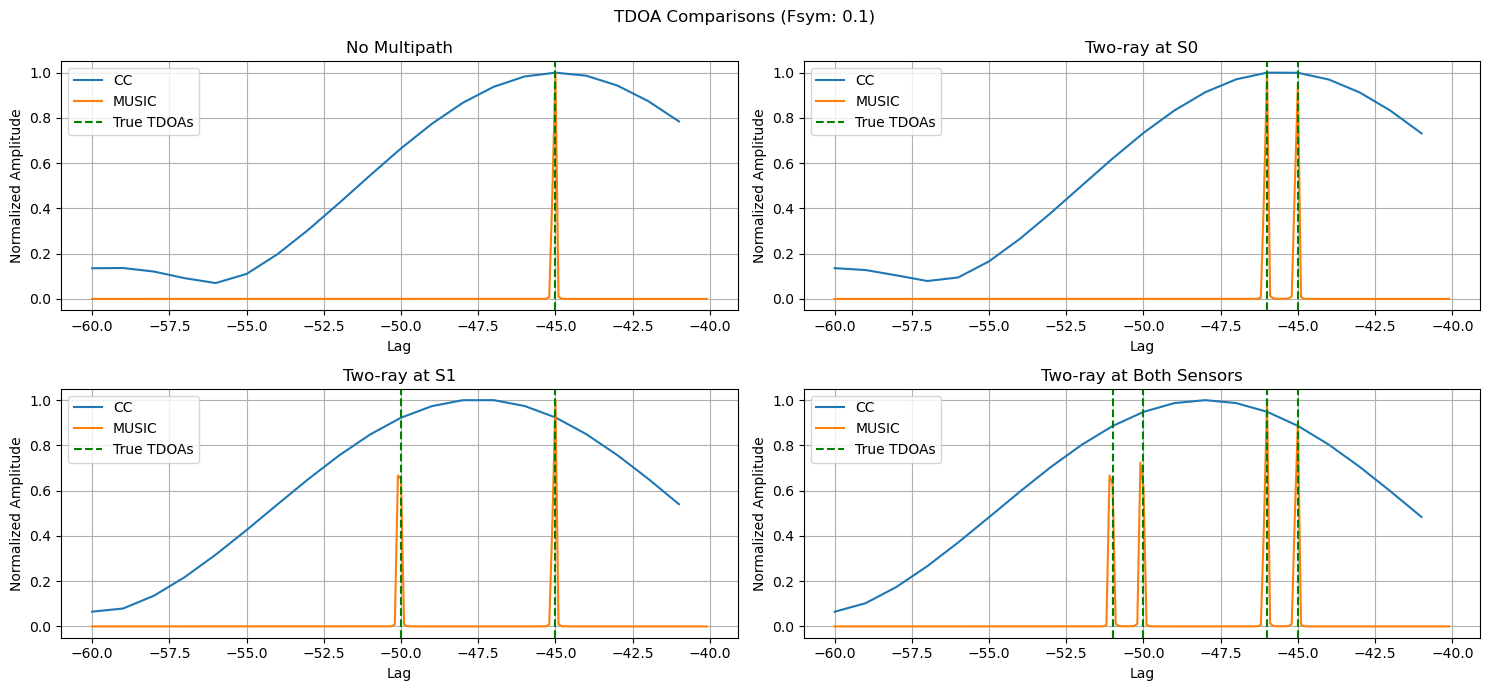

In [2]:
np.random.seed(1234)

num_symbols = 40
samples_per_symbol = 10
signal = utils.random_qpsk_data(num_symbols, samples_per_symbol, utils.Pulse.RAISED_COSINE)

num_samples = num_symbols * samples_per_symbol + 100
print(f"num_samples: {num_samples}")
snr_db = 20.

cases = {
    'No Multipath' : [[20], [65]],
    'Two-ray at S0' : [[20, 19], [65]],
    'Two-ray at S1' : [[20], [65, 70]],
    'Two-ray at Both Sensors' : [[20, 19], [65, 70]]
}

plt.figure(figsize=(15,7))
plt.suptitle(f"TDOA Comparisons (Fsym: {1/samples_per_symbol})")

pltnum = 1
for desc, (toas0, toas1) in cases.items():
    print(f"\ndesc: {desc} toas0: {toas0} toas1: {toas1}")

    snrs0 = [snr_db] * len(toas0)
    y0 = utils.sensor(signal, num_samples, toas0, snrs0)

    snrs1 = [snr_db] * len(toas1)
    y1 = utils.sensor(signal, num_samples, toas1, snrs1)

    true_tdoas = []
    for toa0 in toas0:
        for toa1 in toas1:
            true_tdoas.append(toa0-toa1)
    true_tdoas = list(set(true_tdoas))

    print(f"true_tdoas: {true_tdoas}")

    num_signals = len(true_tdoas)

    fvec = np.linspace(-0.5, 0.5, num_samples)

    l1, tdoa1 = utils.tdoa_cc(y0, y1, lag_min=-60, lag_max=-40)
    l2, tdoa2 = utils.tdoa_super(y0, y1, lag_min=-60, lag_max=-40, k=num_signals, D=10)

    plt.subplot(2,2,pltnum)

    plt.title(desc)
    plt.plot(l1, tdoa1, label='CC')
    plt.plot(l2, tdoa2, label='MUSIC')
    plt.ylabel("Normalized Amplitude")
    plt.xlabel("Lag")
    plt.grid()

    for ix,tdoa in enumerate(true_tdoas):
        if ix==0:
            plt.axvline(tdoa, color='green', linestyle='dashed', label='True TDOAs')
        else:
            plt.axvline(tdoa, color='green', linestyle='dashed')
    plt.legend()

    pltnum += 1

plt.tight_layout()


### Scenario 2

Next we slightly change the TDOAs and again compare the TDOA estimates. In this scenario, we see things perform worse than Scenario 1 after small changes to the TDOAs. I'm not sure why some combinations of TOAs work better than others, but this scenario seems to produce incorrect peaks more frequently than Scenario 1 if run repeatedly. The incorrect detections are still within the cross correlation envelope.

**Case 1**
$\tau_1$ = -45

**Case 1**
$\tau_1$ = -45, $\tau_2$ = -47

**Case 1**
$\tau_1$ = -45, $\tau_2$ = -50

**Case 1**
$\tau_1$ = -45, $\tau_2$ = -47, $\tau_3$ = -50, $\tau_4$ = -52


desc: No Multipath toas0: [20] toas1: [65]
true_tdoas: [-45]

desc: Two-ray at S0 toas0: [20, 18] toas1: [65]
true_tdoas: [-47, -45]

desc: Two-ray at S1 toas0: [20] toas1: [67, 70]
true_tdoas: [-47, -50]

desc: Two-ray at Both Sensors toas0: [20, 18] toas1: [67, 70]
true_tdoas: [-47, -52, -50, -49]


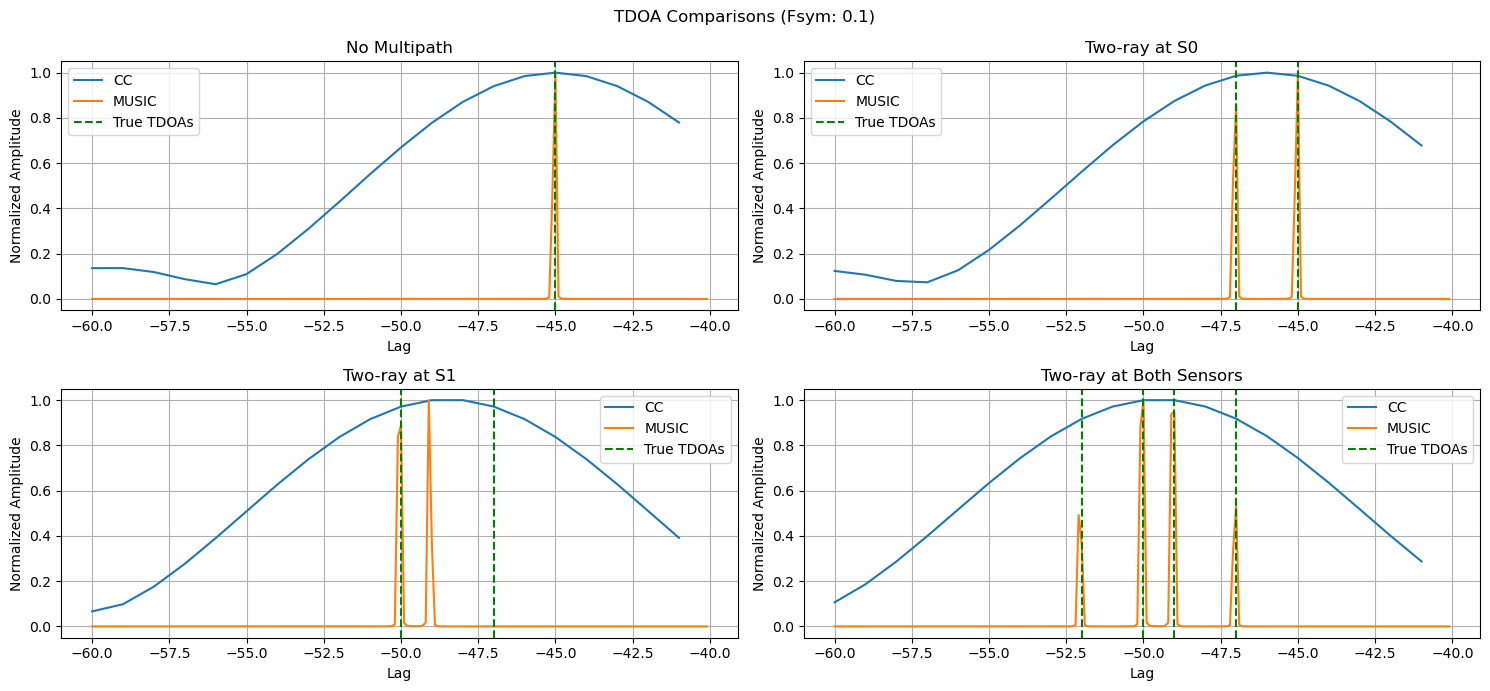

In [3]:
cases = {
    'No Multipath' : [[20], [65]],
    'Two-ray at S0' : [[20, 18], [65]],
    'Two-ray at S1' : [[20], [67, 70]],
    'Two-ray at Both Sensors' : [[20, 18], [67, 70]]
}

plt.figure(figsize=(15,7))
plt.suptitle(f"TDOA Comparisons (Fsym: {1/samples_per_symbol})")

pltnum = 1
for desc, (toas0, toas1) in cases.items():
    print(f"\ndesc: {desc} toas0: {toas0} toas1: {toas1}")

    snrs0 = [snr_db] * len(toas0)
    y0 = utils.sensor(signal, num_samples, toas0, snrs0)

    snrs1 = [snr_db] * len(toas1)
    y1 = utils.sensor(signal, num_samples, toas1, snrs1)

    true_tdoas = []
    for toa0 in toas0:
        for toa1 in toas1:
            true_tdoas.append(toa0-toa1)
    true_tdoas = list(set(true_tdoas))

    print(f"true_tdoas: {true_tdoas}")

    num_signals = len(true_tdoas)

    fvec = np.linspace(-0.5, 0.5, num_samples)

    l1, tdoa1 = utils.tdoa_cc(y0, y1, lag_min=-60, lag_max=-40)
    l2, tdoa2 = utils.tdoa_super(y0, y1, lag_min=-60, lag_max=-40, k=num_signals, D=10)

    plt.subplot(2,2,pltnum)

    plt.title(desc)
    plt.plot(l1, tdoa1, label='CC')
    plt.plot(l2, tdoa2, label='MUSIC')
    plt.ylabel("Normalized Amplitude")
    plt.xlabel("Lag")
    plt.grid()

    for ix,tdoa in enumerate(true_tdoas):
        if ix==0:
            plt.axvline(tdoa, color='green', linestyle='dashed', label='True TDOAs')
        else:
            plt.axvline(tdoa, color='green', linestyle='dashed')
    plt.legend()

    pltnum += 1

plt.tight_layout()

### Summary

We're able to replicate the super-resolution TDOA approach from [2] here with promising albeit somewhat inconsistent results. We would need to run a Monte Carlo over many different possible $\tau$'s to determine how accurate this estimator is on average. The poor performance in Scenario 2 with slight changes to the TDOAs from Scenario 1 is concerning, and I don't understand why it occurs. More investigation would needed there to understand whats happening.
